# Dataset Analysis: UNSW-NB15 for Autonomous Zero-Day Detection

This notebook performs the initial exploratory data analysis (EDA) for the UNSW-NB15 cybersecurity dataset.

UNSW-NB15 is a network-security benchmark used for intrusion detection and cyberattack analysis. In this project, it is being used as the foundation for a satellite-constellation security framework, where distributed satellite nodes will later be simulated by splitting the data into federated subsets.

The current notebook focuses only on dataset understanding and validation. It does not preprocess, encode, scale, balance, or train any model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

candidate_roots = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path(r'e:/Autonomous_Zero_Day_Detection'),
    Path(r'e:\Autonomous_Zero_Day_Detection'),
]

project_root = None
for root in candidate_roots:
    if (root / 'dataset').exists():
        project_root = root
        break

if project_root is None:
    raise FileNotFoundError('Project root not found. Please run this notebook from the project directory.')

project_root = project_root.resolve()
data_dir = project_root / 'dataset' / 'UNSW-NB15'
plots_dir = project_root / 'results' / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

train_path = data_dir / 'UNSW_NB15_training-set.csv'
test_path = data_dir / 'UNSW_NB15_testing-set.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f'Project root: {project_root}')
print(f'Training dataset path: {train_path}')
print(f'Testing dataset path: {test_path}')
print(f'\nTraining shape: {train_df.shape}')
print(f'Testing shape: {test_df.shape}')
print('\nFirst 5 rows of the training set:')
display(train_df.head())
print('\nLast 5 rows of the training set:')
display(train_df.tail())
print('\nFirst 5 rows of the testing set:')
display(test_df.head())
print('\nLast 5 rows of the testing set:')
display(test_df.tail())

Project root: C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection
Training dataset path: C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\dataset\UNSW-NB15\UNSW_NB15_training-set.csv
Testing dataset path: C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\dataset\UNSW-NB15\UNSW_NB15_testing-set.csv

Training shape: (175341, 45)
Testing shape: (82332, 45)

First 5 rows of the training set:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.1215,tcp,-,FIN,6,4,258,172,74.0875,252,254,14158.9424,8495.3652,0,0,24.2956,8.3750,30.1775,11.8306,255,621772692,2202533631,255,0.0000,0.0000,0.0000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.6499,tcp,-,FIN,14,38,734,42014,78.4734,62,252,8395.1123,503571.3125,2,17,49.9150,15.4329,61.4269,1387.7783,255,1417884146,3077387971,255,0.0000,0.0000,0.0000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.6231,tcp,-,FIN,8,16,364,13186,14.1702,62,252,1572.2719,60929.2305,1,6,231.8756,102.7372,17179.5869,11420.9262,255,2116150707,2963114973,255,0.1119,0.0615,0.0504,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.6816,tcp,ftp,FIN,12,12,628,770,13.6771,62,252,2740.1790,3358.6221,1,3,152.8765,90.2357,259.0802,4991.7847,255,1107119177,1047442890,255,0.0000,0.0000,0.0000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.4495,tcp,-,FIN,10,6,534,268,33.3738,254,252,8561.4990,3987.0598,2,1,47.7503,75.6596,2415.8376,115.8070,255,2436137549,1977154190,255,0.1284,0.0711,0.0572,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0



Last 5 rows of the training set:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
175336,175337,0.0000,udp,dns,INT,2,0,114,0,111111.1072,254,0,50666664.0000,0.0000,0,0,0.0090,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,57,0,0,0,24,2,24,24,13,24,0,0,0,24,24,0,Generic,1
175337,175338,0.5058,tcp,-,FIN,10,8,620,354,33.6126,254,252,8826.2861,4903.4922,2,1,54.4001,66.9806,3721.0688,120.1777,255,3518776216,3453092386,255,0.0994,0.0369,0.0625,62,44,0,0,1,1,1,1,1,2,0,0,0,1,1,0,Shellcode,1
175338,175339,0.0000,udp,dns,INT,2,0,114,0,111111.1072,254,0,50666664.0000,0.0000,0,0,0.0090,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,57,0,0,0,12,2,3,3,3,13,0,0,0,3,12,0,Generic,1
175339,175340,0.0000,udp,dns,INT,2,0,114,0,111111.1072,254,0,50666664.0000,0.0000,0,0,0.0090,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,57,0,0,0,30,2,30,30,14,30,0,0,0,30,30,0,Generic,1
175340,175341,0.0000,udp,dns,INT,2,0,114,0,111111.1072,254,0,50666664.0000,0.0000,0,0,0.0090,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,57,0,0,0,30,2,30,30,16,30,0,0,0,30,30,0,Generic,1



First 5 rows of the testing set:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.0000,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0000,0.0000,0,0,0.0110,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.0000,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0000,0.0000,0,0,0.0080,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.0000,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0000,0.0000,0,0,0.0050,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.0000,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0000,0.0000,0,0,0.0060,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.0000,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0000,0.0000,0,0,0.0100,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0



Last 5 rows of the testing set:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
82327,82328,0.0000,udp,-,INT,2,0,104,0,200000.0051,254,0,83200000.0000,0.0000,0,0,0.0050,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,52,0,0,0,1,2,2,1,1,2,0,0,0,2,1,0,Normal,0
82328,82329,1.1061,tcp,-,FIN,20,8,18062,354,24.4101,254,252,124104.3984,2242.1099,7,1,55.8801,143.7000,4798.1310,190.9808,255,1072535109,3284291478,255,0.1732,0.1002,0.0730,903,44,0,0,1,1,2,1,1,1,0,0,0,3,2,0,Normal,0
82329,82330,0.0000,arp,-,INT,1,0,46,0,0.0000,0,0,0.0000,0.0000,0,0,60000.7200,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,46,0,0,0,1,2,1,1,1,1,0,0,0,1,1,1,Normal,0
82330,82331,0.0000,arp,-,INT,1,0,46,0,0.0000,0,0,0.0000,0.0000,0,0,60000.7320,0.0000,10.9545,0.0000,0,0,0,0,0.0000,0.0000,0.0000,46,0,0,0,1,2,1,1,1,1,0,0,0,1,1,1,Normal,0
82331,82332,0.0000,udp,-,INT,2,0,104,0,111111.1072,254,0,46222220.0000,0.0000,0,0,0.0090,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,52,0,0,0,1,2,1,1,1,1,0,0,0,1,1,0,Normal,0


In [2]:
train_cols = list(train_df.columns)
test_cols = list(test_df.columns)

print('Training columns:')
print(train_cols)
print('\nTesting columns:')
print(test_cols)

print('\nTraining dtypes:')
print(train_df.dtypes.to_string())
print('\nTesting dtypes:')
print(test_df.dtypes.to_string())

print(f'\nTraining numeric columns: {train_df.select_dtypes(include=[np.number]).shape[1]}')
print(f'Training categorical columns: {train_df.select_dtypes(exclude=[np.number]).shape[1]}')
print(f'Testing numeric columns: {test_df.select_dtypes(include=[np.number]).shape[1]}')
print(f'Testing categorical columns: {test_df.select_dtypes(exclude=[np.number]).shape[1]}')

missing_train = train_df.isna().sum()
missing_test = test_df.isna().sum()
print('\nMissing values in training set:')
print(missing_train[missing_train > 0].to_string() if (missing_train > 0).any() else 'No missing values in training set.')
print('\nMissing values in testing set:')
print(missing_test[missing_test > 0].to_string() if (missing_test > 0).any() else 'No missing values in testing set.')

print(f'\nDuplicate rows in training set: {train_df.duplicated().sum()}')
print(f'Duplicate rows in testing set: {test_df.duplicated().sum()}')

Training columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Testing columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 


Duplicate rows in training set: 0
Duplicate rows in testing set: 0


In [3]:
def show_label_summary(df, name):
    if 'label' in df.columns:
        label_counts = df['label'].value_counts().sort_index()
        label_pct = df['label'].value_counts(normalize=True).sort_index() * 100
        print(f'\n{name} label distribution:')
        label_summary = pd.concat([label_counts, label_pct], axis=1)
        label_summary.columns = ['Count', 'Percentage (%)']
        display(label_summary)
    else:
        print(f'\n{name} does not contain a label column.')

show_label_summary(train_df, 'Training')
show_label_summary(test_df, 'Testing')

if 'attack_cat' in train_df.columns:
    train_attack_counts = train_df['attack_cat'].value_counts()
    train_attack_pct = train_df['attack_cat'].value_counts(normalize=True) * 100
    train_attack_summary = pd.concat([train_attack_counts, train_attack_pct], axis=1)
    train_attack_summary.columns = ['Count', 'Percentage (%)']
    print('\nTraining attack category distribution:')
    display(train_attack_summary)
else:
    print('\nTraining set does not contain attack_cat column.')

if 'attack_cat' in test_df.columns:
    test_attack_counts = test_df['attack_cat'].value_counts()
    test_attack_pct = test_df['attack_cat'].value_counts(normalize=True) * 100
    test_attack_summary = pd.concat([test_attack_counts, test_attack_pct], axis=1)
    test_attack_summary.columns = ['Count', 'Percentage (%)']
    print('\nTesting attack category distribution:')
    display(test_attack_summary)
else:
    print('\nTesting set does not contain attack_cat column.')

print(f"\nLabel column present in training set: {'label' in train_df.columns}")
print(f"Label column present in testing set: {'label' in test_df.columns}")
print(f"Attack category column present in training set: {'attack_cat' in train_df.columns}")
print(f"Attack category column present in testing set: {'attack_cat' in test_df.columns}")


Training label distribution:


,Count,Percentage (%)
label,,
0,56000,31.9378
1,119341,68.0622



Testing label distribution:


,Count,Percentage (%)
label,,
0,37000,44.9400
1,45332,55.0600



Training attack category distribution:


,Count,Percentage (%)
attack_cat,,
Normal,56000,31.9378
Generic,40000,22.8127
Exploits,33393,19.0446
Fuzzers,18184,10.3706
DoS,12264,6.9944
Reconnaissance,10491,5.9832
Analysis,2000,1.1406
Backdoor,1746,0.9958
Shellcode,1133,0.6462



Testing attack category distribution:


,Count,Percentage (%)
attack_cat,,
Normal,37000,44.9400
Generic,18871,22.9206
Exploits,11132,13.5209
Fuzzers,6062,7.3629
DoS,4089,4.9665
Reconnaissance,3496,4.2462
Analysis,677,0.8223
Backdoor,583,0.7081
Shellcode,378,0.4591



Label column present in training set: True
Label column present in testing set: True
Attack category column present in training set: True
Attack category column present in testing set: True


In [4]:
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_df.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numerical features:')
print(numeric_features)
print('\nCategorical features:')
print(categorical_features)

print('\nDescriptive statistics for numerical features (training set):')
display(train_df[numeric_features].describe().T)

print('\nUnique values summary for categorical features (training set):')
for col in categorical_features:
    print(f'\n{col}: {train_df[col].nunique()} unique values')
    display(train_df[col].value_counts().head(10))

Numerical features:
['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label']

Categorical features:
['proto', 'service', 'state', 'attack_cat']

Descriptive statistics for numerical features (training set):


,count,mean,std,min,25%,50%,75%,max
id,175341.0000,87671.0000,50616.7311,1.0000,43836.0000,87671.0000,131506.0000,175341.0000
dur,175341.0000,1.3594,6.4802,0.0000,0.0000,0.0016,0.6681,60.0000
spkts,175341.0000,20.2987,136.8876,1.0000,2.0000,2.0000,12.0000,9616.0000
dpkts,175341.0000,18.9696,110.2583,0.0000,0.0000,2.0000,10.0000,10974.0000
sbytes,175341.0000,8844.8438,174765.6443,28.0000,114.0000,430.0000,1418.0000,12965233.0000
dbytes,175341.0000,14928.9186,143654.2177,0.0000,0.0000,164.0000,1102.0000,14655550.0000
rate,175341.0000,95406.1871,165400.9785,0.0000,32.7861,3225.8065,125000.0003,1000000.0030
sttl,175341.0000,179.5470,102.9400,0.0000,62.0000,254.0000,254.0000,255.0000
dttl,175341.0000,79.6096,110.5069,0.0000,0.0000,29.0000,252.0000,254.0000
sload,175341.0000,73454033.1941,188357447.0002,0.0000,13053.3389,879674.7500,88888888.0000,5988000256.0000



Unique values summary for categorical features (training set):

proto: 133 unique values


proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
ipv6        201
mobile      201
Name: count, dtype: int64


service: 13 unique values


service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64


state: 9 unique values


state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


attack_cat: 10 unique values


attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

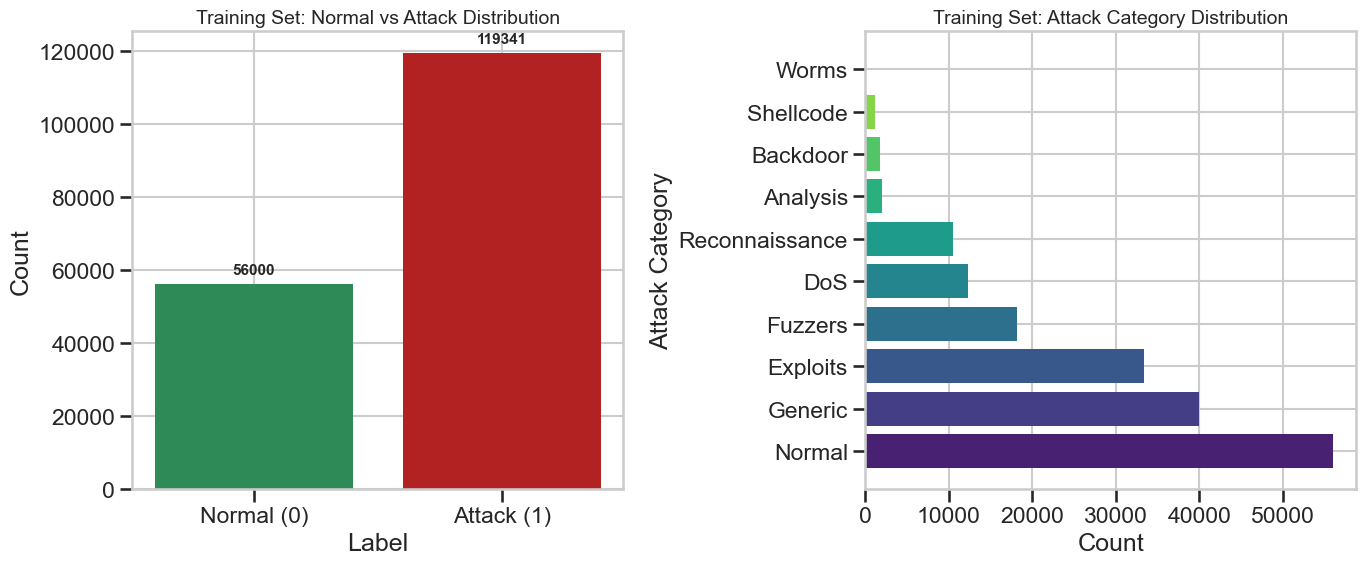

Training label percentages:
{0: 31.94, 1: 68.06}

Training attack category percentages:
{'Normal': 31.94, 'Generic': 22.81, 'Exploits': 19.04, 'Fuzzers': 10.37, 'DoS': 6.99, 'Reconnaissance': 5.98, 'Analysis': 1.14, 'Backdoor': 1.0, 'Shellcode': 0.65, 'Worms': 0.07}


In [5]:
train_label_counts = train_df['label'].value_counts().sort_index()
train_label_pct = train_label_counts / train_label_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar([0, 1], train_label_counts.values, color=['#2E8B57', '#B22222'])
axes[0].set_title('Training Set: Normal vs Attack Distribution', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'])
for x, y in zip([0, 1], train_label_counts.values):
    axes[0].text(x, y + 2000, f'{y}', ha='center', va='bottom', fontsize=11, fontweight='bold')

train_attack_counts = train_df['attack_cat'].value_counts()
attack_palette = sns.color_palette('viridis', len(train_attack_counts))
axes[1].barh(train_attack_counts.index, train_attack_counts.values, color=attack_palette)
axes[1].set_title('Training Set: Attack Category Distribution', fontsize=14)
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Attack Category')

fig.tight_layout()
fig.savefig(plots_dir / 'training_label_and_attack_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Training label percentages:')
print(train_label_pct.round(2).to_dict())
print('\nTraining attack category percentages:')
print((train_attack_counts / train_attack_counts.sum() * 100).round(2).to_dict())

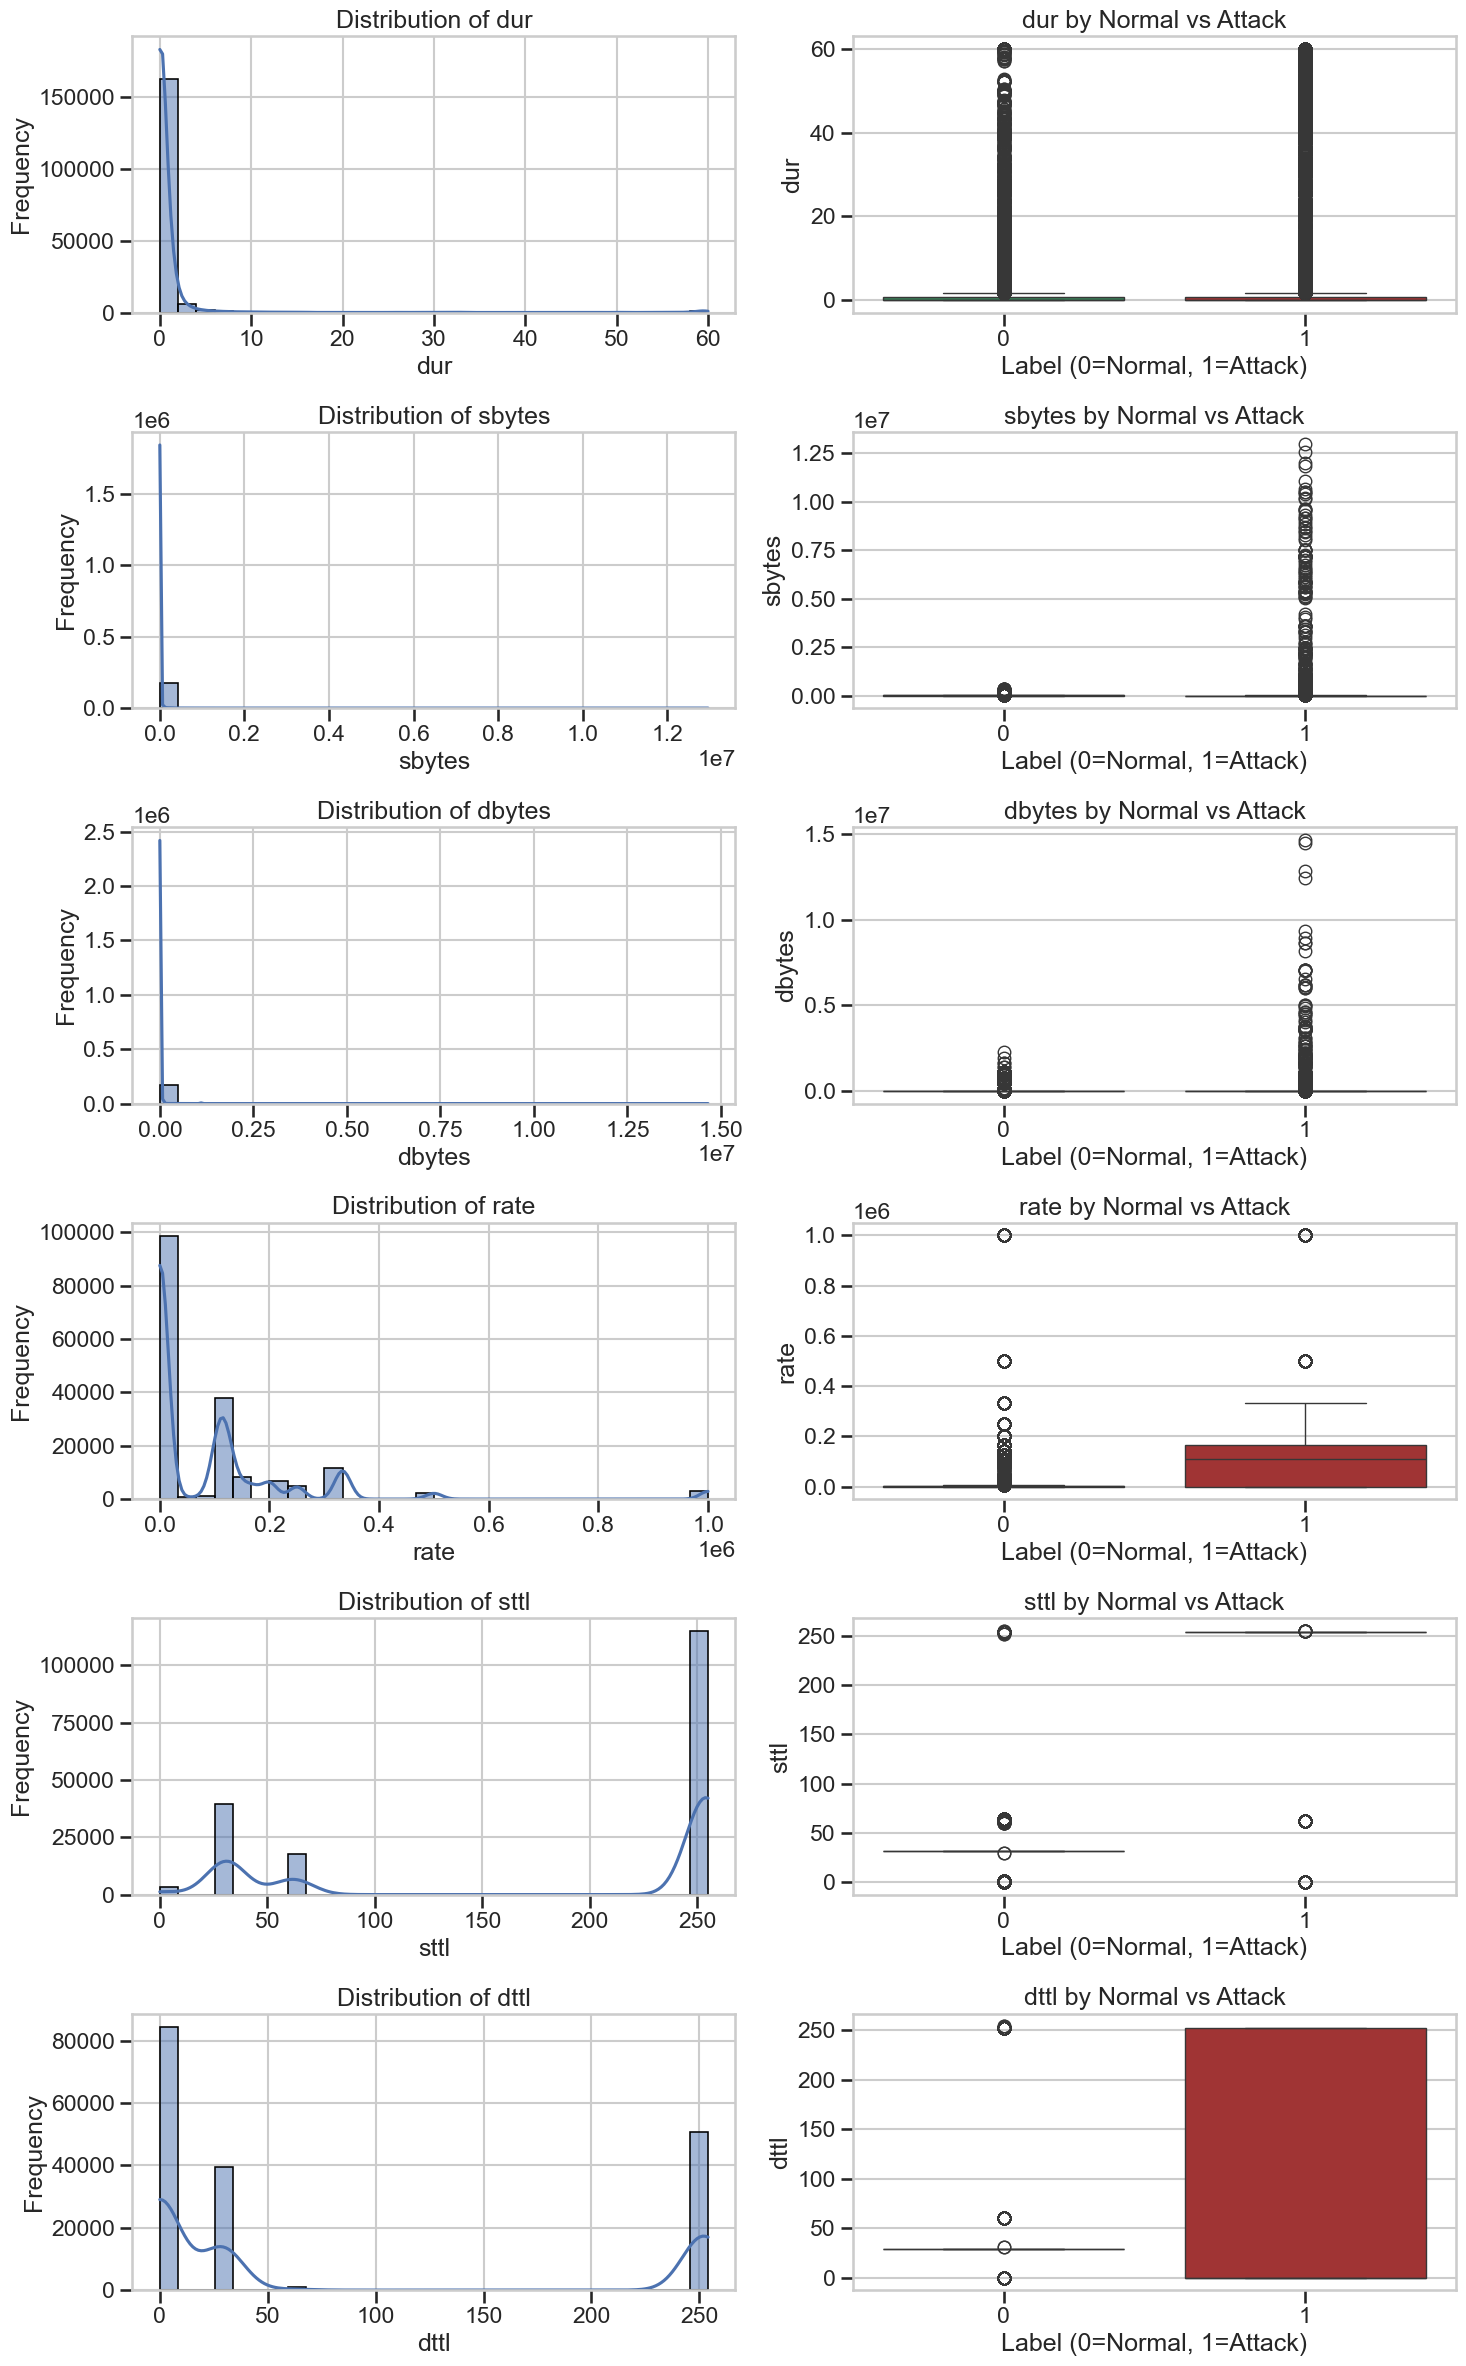

In [6]:
key_numeric_cols = ['dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl']
selected_numeric = [col for col in key_numeric_cols if col in train_df.columns]

fig, axes = plt.subplots(len(selected_numeric), 2, figsize=(15, 4 * len(selected_numeric)))
if len(selected_numeric) == 1:
    axes = np.array([axes]).reshape(1, 2)
for i, col in enumerate(selected_numeric):
    sns.histplot(train_df[col], bins=30, kde=True, ax=axes[i, 0], color='#4C72B0')
    axes[i, 0].set_title(f'Distribution of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    sns.boxplot(x='label', y=col, data=train_df, palette=['#2E8B57', '#B22222'], hue='label', dodge=False, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} by Normal vs Attack')
    axes[i, 1].set_xlabel('Label (0=Normal, 1=Attack)')
    axes[i, 1].set_ylabel(col)
    axes[i, 1].legend([], frameon=False)

fig.tight_layout()
fig.savefig(plots_dir / 'numeric_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

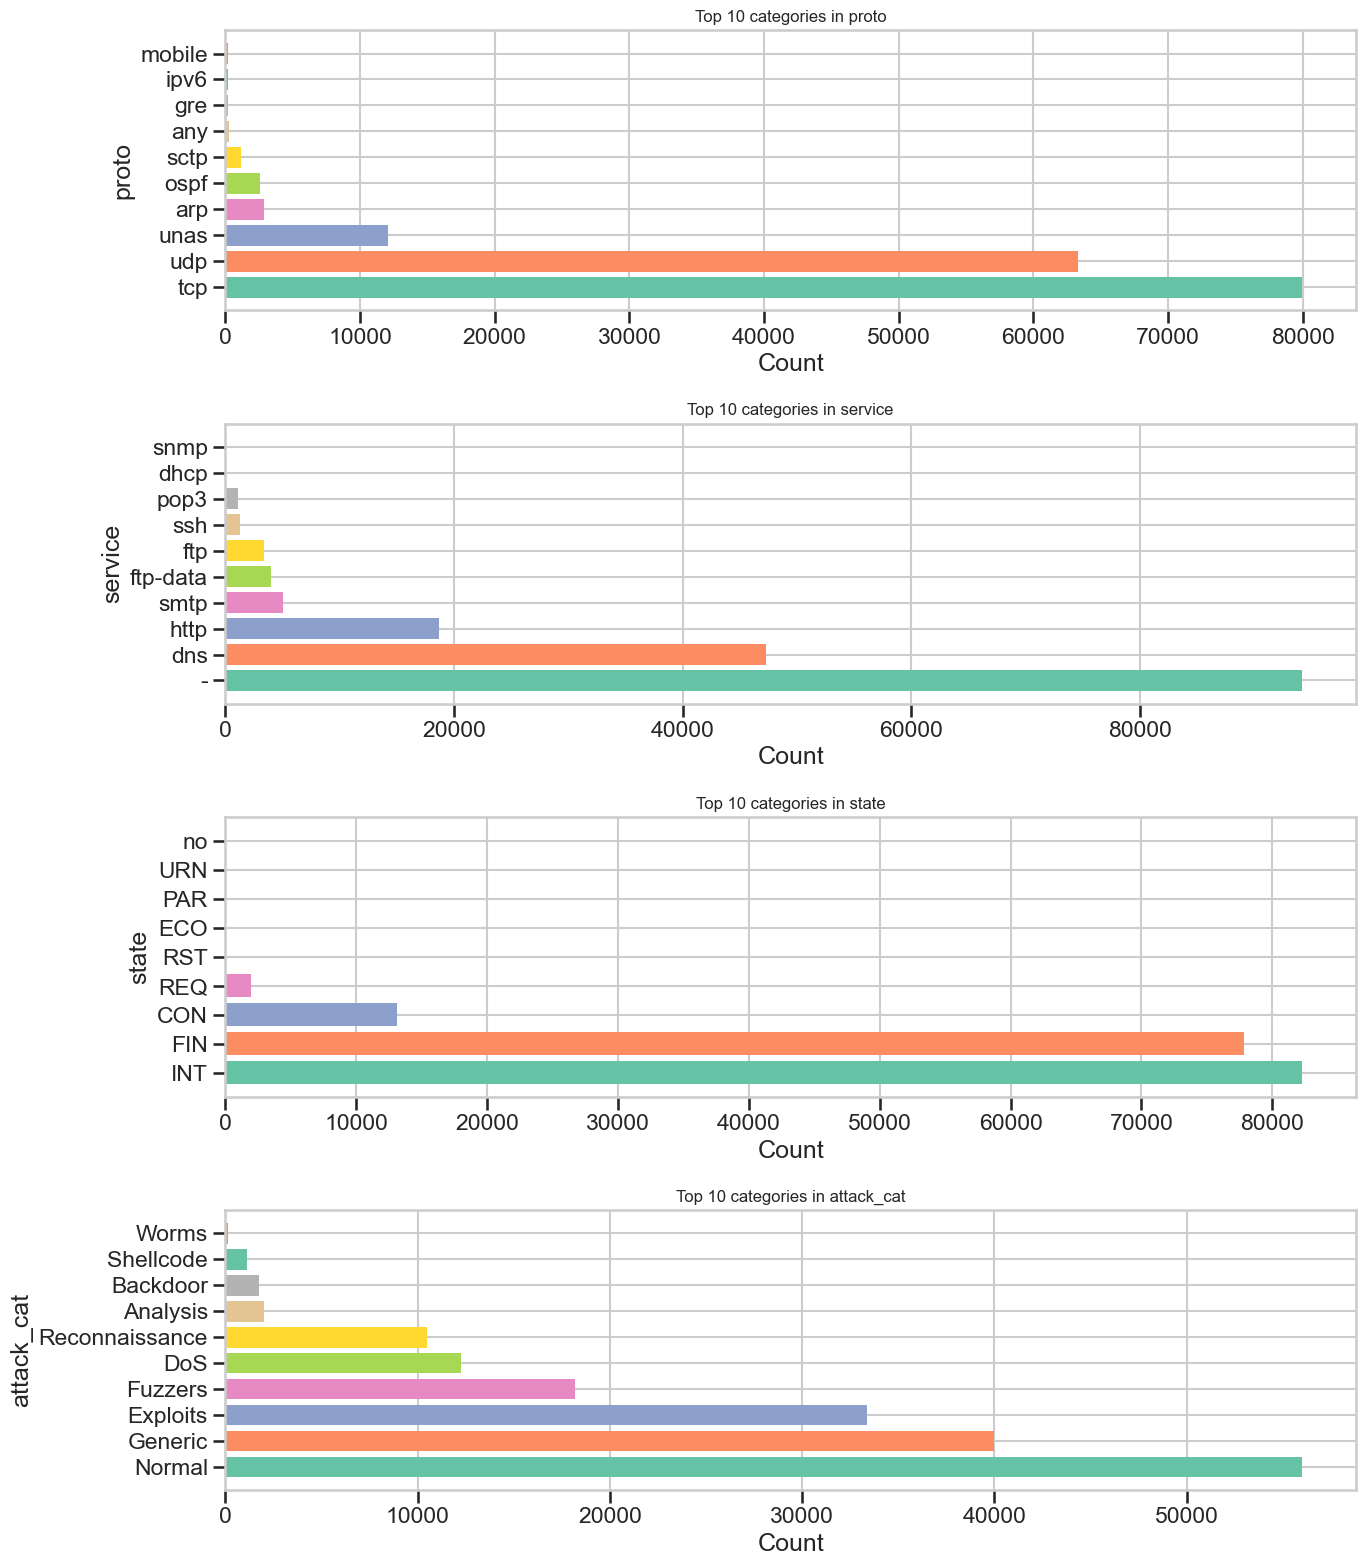

In [7]:
categorical_cols = ['proto', 'service', 'state', 'attack_cat']
selected_categorical = [col for col in categorical_cols if col in train_df.columns]

fig, axes = plt.subplots(len(selected_categorical), 1, figsize=(14, 4 * len(selected_categorical)))
if len(selected_categorical) == 1:
    axes = [axes]
for i, col in enumerate(selected_categorical):
    value_counts = train_df[col].value_counts().head(10)
    axes[i].barh(value_counts.index, value_counts.values, color=sns.color_palette('Set2', len(value_counts)))
    axes[i].set_title(f'Top 10 categories in {col}', fontsize=12)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)

fig.tight_layout()
fig.savefig(plots_dir / 'categorical_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

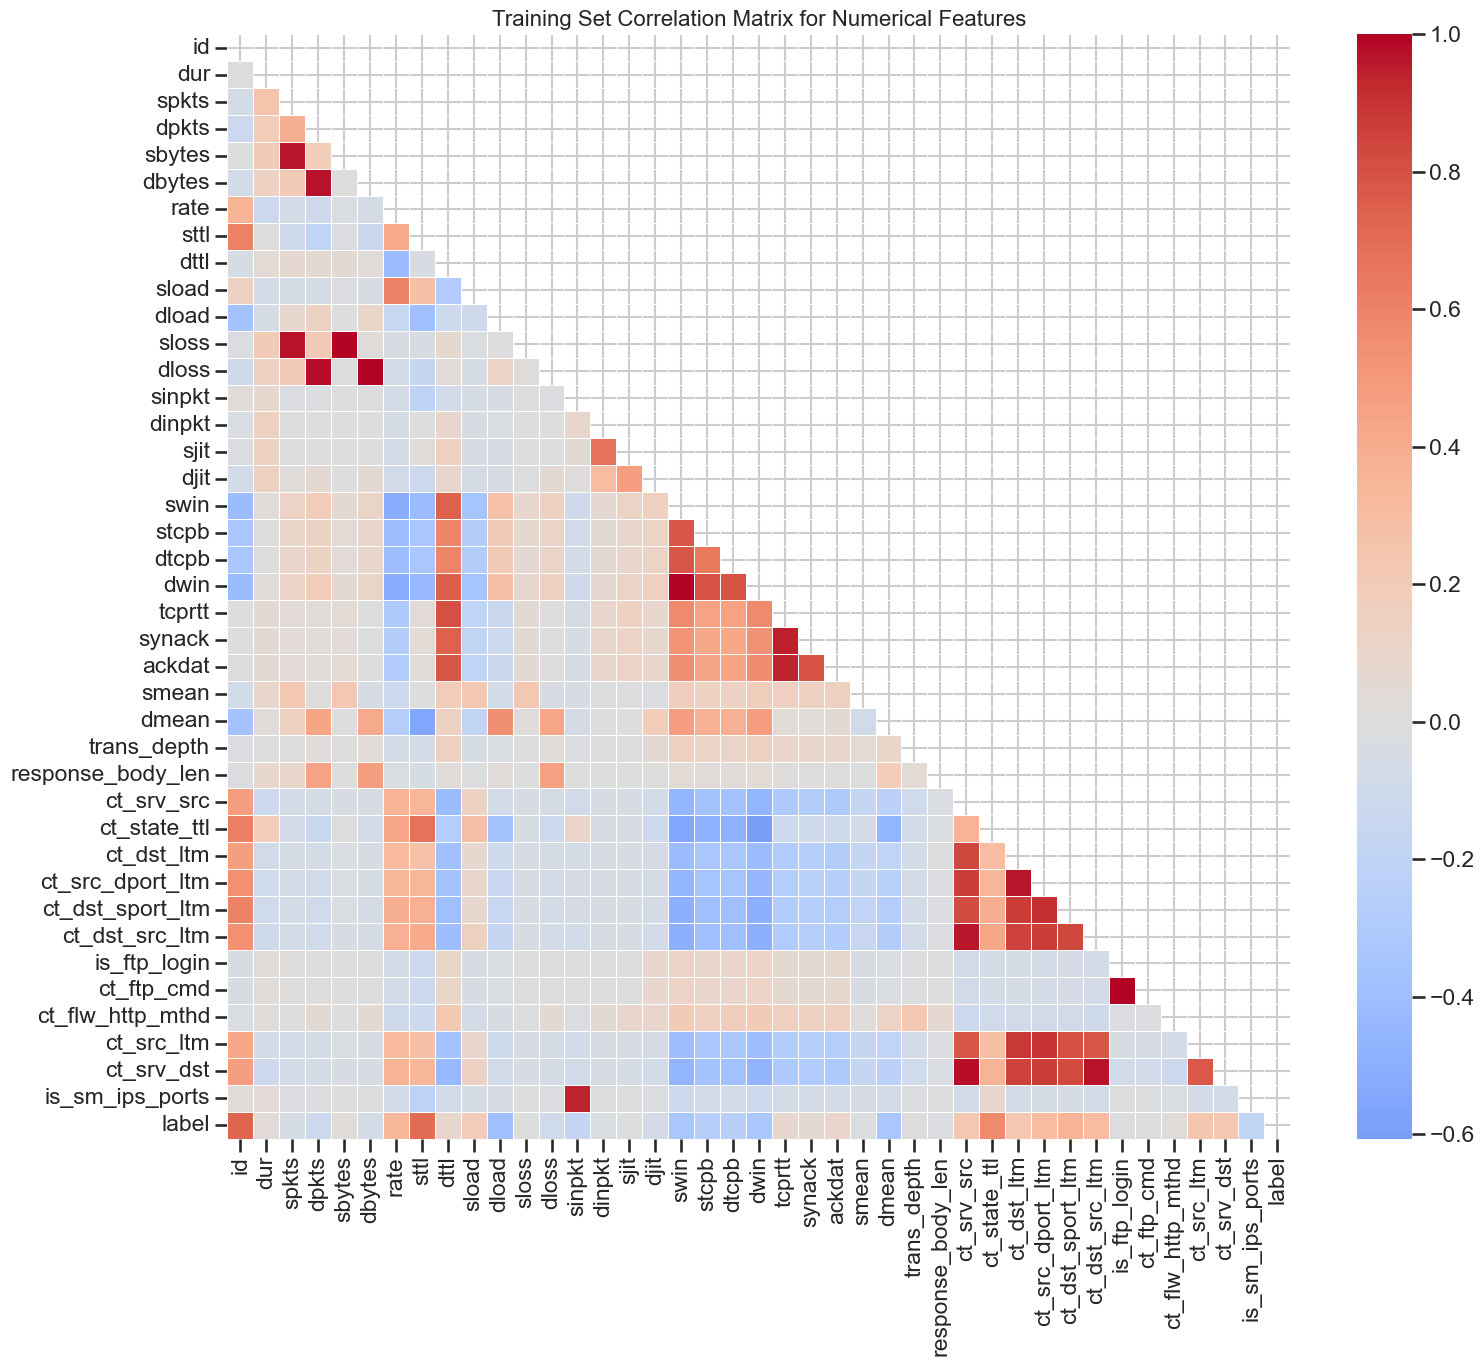

Top positive correlations with label:
id                 0.7272
sttl               0.6927
ct_state_ttl       0.5777
ct_dst_sport_ltm   0.3572
rate               0.3380
ct_src_dport_ltm   0.3056
ct_dst_src_ltm     0.3039
ct_src_ltm         0.2382
ct_dst_ltm         0.2299
ct_srv_src         0.2290

Top negative correlations with label:
dload             -0.3937
dmean             -0.3418
swin              -0.3336
dwin              -0.3196
stcpb             -0.2550
dtcpb             -0.2503
is_sm_ips_ports   -0.1847
sinpkt            -0.1761
dpkts             -0.1186
dloss             -0.0947


In [8]:
numeric_df = train_df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.5,
    cbar=True,
    square=False,
    ax=ax
)
ax.set_title('Training Set Correlation Matrix for Numerical Features', fontsize=16)
fig.tight_layout()
fig.savefig(plots_dir / 'training_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('Top positive correlations with label:')
label_corr = correlation_matrix['label'].drop('label').sort_values(ascending=False)
print(label_corr.head(10).to_string())
print('\nTop negative correlations with label:')
print(label_corr.tail(10).sort_values().to_string())

Label counts by split:


,Training,Testing
Normal (0),56000,37000
Attack (1),119341,45332



Attack category counts by split:


,Training,Testing
attack_cat,,
Normal,56000,37000
Generic,40000,18871
Exploits,33393,11132
Fuzzers,18184,6062
DoS,12264,4089
Reconnaissance,10491,3496
Analysis,2000,677
Backdoor,1746,583
Shellcode,1133,378


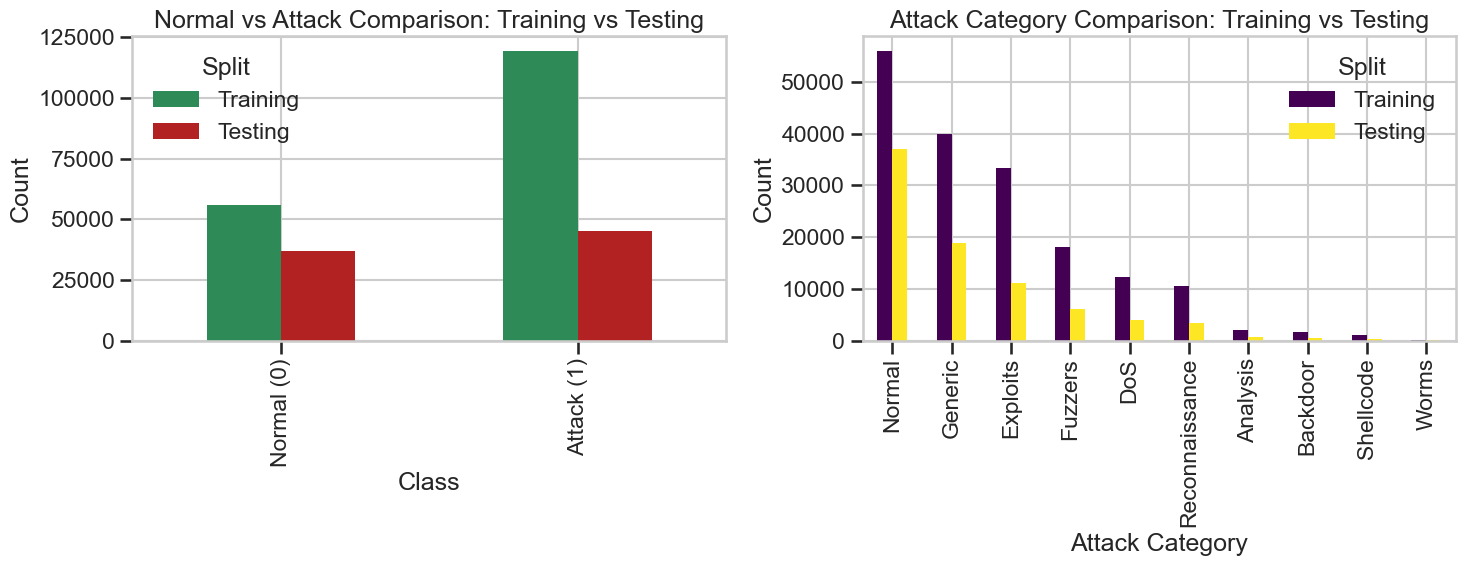

In [9]:
train_label_distribution = train_df['label'].value_counts().sort_index()
test_label_distribution = test_df['label'].value_counts().sort_index()
combined_label = pd.concat([train_label_distribution, test_label_distribution], axis=1, keys=['Training', 'Testing'])
combined_label.index = ['Normal (0)', 'Attack (1)']
print('Label counts by split:')
display(combined_label)

train_attack_distribution = train_df['attack_cat'].value_counts()
test_attack_distribution = test_df['attack_cat'].value_counts()
attack_comparison = pd.concat([train_attack_distribution, test_attack_distribution], axis=1, keys=['Training', 'Testing']).fillna(0)
print('\nAttack category counts by split:')
display(attack_comparison.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
combined_label.plot(kind='bar', ax=axes[0], color=['#2E8B57', '#B22222'])
axes[0].set_title('Normal vs Attack Comparison: Training vs Testing')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].legend(title='Split')

attack_comparison.plot(kind='bar', ax=axes[1], figsize=(15, 6), colormap='viridis')
axes[1].set_title('Attack Category Comparison: Training vs Testing')
axes[1].set_xlabel('Attack Category')
axes[1].set_ylabel('Count')
axes[1].legend(title='Split')
fig.tight_layout()
fig.savefig(plots_dir / 'train_vs_test_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
combined_train_test = pd.concat([train_df, test_df], ignore_index=True, sort=False)
combined_attack_table = combined_train_test['attack_cat'].value_counts().sort_values(ascending=False)
combined_attack_pct = combined_attack_table / combined_attack_table.sum() * 100
combined_attack_summary = pd.concat([combined_attack_table, combined_attack_pct], axis=1)
combined_attack_summary.columns = ['Count', 'Percentage (%)']
print('Combined attack category summary across training and testing sets:')
display(combined_attack_summary)

summary = pd.DataFrame({
    'Metric': [
        'Training samples',
        'Testing samples',
        'Number of features',
        'Numerical features',
        'Categorical features',
        'Missing values',
        'Duplicate records',
        'Normal samples',
        'Attack samples',
        'Attack categories'
    ],
    'Value': [
        int(train_df.shape[0]),
        int(test_df.shape[0]),
        int(train_df.shape[1]),
        int(train_df.select_dtypes(include=[np.number]).shape[1]),
        int(train_df.select_dtypes(exclude=[np.number]).shape[1]),
        int(train_df.isna().sum().sum() + test_df.isna().sum().sum()),
        int(train_df.duplicated().sum() + test_df.duplicated().sum()),
        int((train_df['label'] == 0).sum() + (test_df['label'] == 0).sum()),
        int((train_df['label'] == 1).sum() + (test_df['label'] == 1).sum()),
        ', '.join(sorted(combined_attack_summary.index.tolist()))
    ]
})

print('\nDataset Analysis Summary:')
display(summary)

Combined attack category summary across training and testing sets:


,Count,Percentage (%)
attack_cat,,
Normal,93000,36.0923
Generic,58871,22.8472
Exploits,44525,17.2797
Fuzzers,24246,9.4096
DoS,16353,6.3464
Reconnaissance,13987,5.4282
Analysis,2677,1.0389
Backdoor,2329,0.9039
Shellcode,1511,0.5864



Dataset Analysis Summary:


,Metric,Value
0,Training samples,175341
1,Testing samples,82332
2,Number of features,45
3,Numerical features,41
4,Categorical features,4
5,Missing values,0
6,Duplicate records,0
7,Normal samples,93000
8,Attack samples,164673
9,Attack categories,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Ge..."
